In [ ]:
!pip install -q emnist

In [ ]:
!pip uninstall -y tensorflow-datasets tensorflow-metadata protobuf -q
!pip install -q tensorflow-datasets tensorflow-metadata protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 31.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.


In [ ]:
import tensorflow_datasets as tfds

print("TFDS version:", tfds.__version__)

TFDS version: 4.9.10


In [ ]:
import os
import gzip
import struct
import urllib.request
import numpy as np

DATA_DIR = "/content/emnist_byclass"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://huggingface.co/datasets/Royc30ne/emnist-byclass/resolve/main/"

files = {
    "train_images": "emnist-byclass-train-images-idx3-ubyte.gz",
    "train_labels": "emnist-byclass-train-labels-idx1-ubyte.gz",
    "test_images": "emnist-byclass-test-images-idx3-ubyte.gz",
    "test_labels": "emnist-byclass-test-labels-idx1-ubyte.gz",
    "mapping": "emnist-byclass-mapping.txt"
}

for key, filename in files.items():
    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        print(f"Downloading: {filename}")
        urllib.request.urlretrieve(BASE_URL + filename, path)
        print("Downloaded.")
    else:
        print(f"Already exists: {filename}")

Downloading: emnist-byclass-train-images-idx3-ubyte.gz
Downloaded.
Downloading: emnist-byclass-train-labels-idx1-ubyte.gz
Downloaded.
Downloading: emnist-byclass-test-images-idx3-ubyte.gz
Downloaded.
Downloading: emnist-byclass-test-labels-idx1-ubyte.gz
Downloaded.
Downloading: emnist-byclass-mapping.txt
Downloaded.


In [ ]:
import os
import gzip
import struct
import numpy as np

def load_emnist_images(filename):
    with gzip.open(filename, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        images = data.reshape(num_images, rows, cols)

    # EMNIST orientation correction
    images = np.transpose(images, (0, 2, 1))

    return images


def load_emnist_labels(filename):
    with gzip.open(filename, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))

        labels = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

    return labels


# Load training data
X_train = load_emnist_images(
    os.path.join(DATA_DIR, files["train_images"])
)

y_train = load_emnist_labels(
    os.path.join(DATA_DIR, files["train_labels"])
)

# Load testing data
X_test = load_emnist_images(
    os.path.join(DATA_DIR, files["test_images"])
)

y_test = load_emnist_labels(
    os.path.join(DATA_DIR, files["test_labels"])
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (697932, 28, 28)
y_train: (697932,)
X_test : (116323, 28, 28)
y_test : (116323,)


In [ ]:
mapping_path = os.path.join(DATA_DIR, files["mapping"])

label_mapping = {}

with open(mapping_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            label = int(parts[0])
            ascii_code = int(parts[1])
            label_mapping[label] = chr(ascii_code)

print("Total classes:", len(label_mapping))

for i in range(62):
    print(i, "->", label_mapping[i])

Total classes: 62
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
8 -> 8
9 -> 9
10 -> A
11 -> B
12 -> C
13 -> D
14 -> E
15 -> F
16 -> G
17 -> H
18 -> I
19 -> J
20 -> K
21 -> L
22 -> M
23 -> N
24 -> O
25 -> P
26 -> Q
27 -> R
28 -> S
29 -> T
30 -> U
31 -> V
32 -> W
33 -> X
34 -> Y
35 -> Z
36 -> a
37 -> b
38 -> c
39 -> d
40 -> e
41 -> f
42 -> g
43 -> h
44 -> i
45 -> j
46 -> k
47 -> l
48 -> m
49 -> n
50 -> o
51 -> p
52 -> q
53 -> r
54 -> s
55 -> t
56 -> u
57 -> v
58 -> w
59 -> x
60 -> y
61 -> z


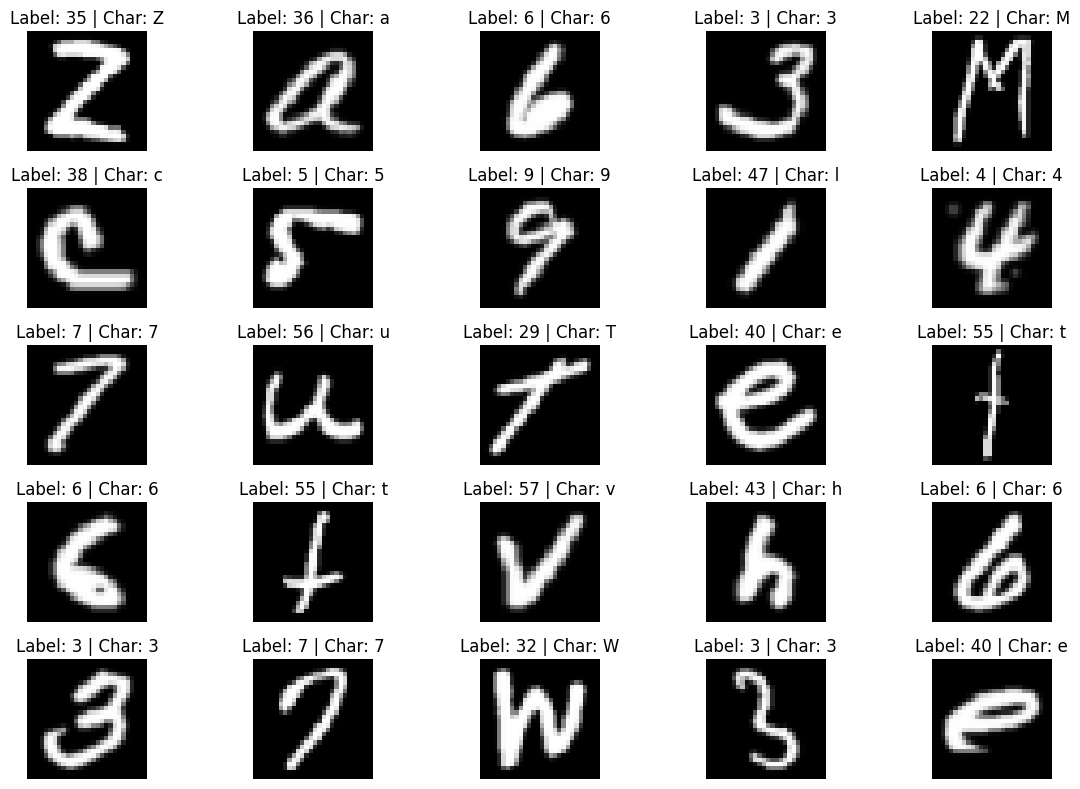

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    label = y_train[i]
    character = label_mapping[int(label)]

    plt.title(f"Label: {label} | Char: {character}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

class_counts = Counter(y_train)

print("Number of classes:", len(class_counts))
print("\nClass distribution:")

for label in sorted(class_counts):
    print(
        f"{label:2d} -> {label_mapping[int(label)]} : {class_counts[label]}"
    )

Number of classes: 62

Class distribution:
 0 -> 0 : 34585
 1 -> 1 : 38374
 2 -> 2 : 34203
 3 -> 3 : 35143
 4 -> 4 : 33535
 5 -> 5 : 31416
 6 -> 6 : 34232
 7 -> 7 : 35754
 8 -> 8 : 33946
 9 -> 9 : 33847
10 -> A : 6407
11 -> B : 3878
12 -> C : 10094
13 -> D : 4562
14 -> E : 4934
15 -> F : 9182
16 -> G : 2517
17 -> H : 3152
18 -> I : 11946
19 -> J : 3762
20 -> K : 2468
21 -> L : 5076
22 -> M : 9002
23 -> N : 8237
24 -> O : 24983
25 -> P : 8347
26 -> Q : 2605
27 -> R : 5073
28 -> S : 20764
29 -> T : 9820
30 -> U : 12602
31 -> V : 4637
32 -> W : 4695
33 -> X : 2771
34 -> Y : 4743
35 -> Z : 2701
36 -> a : 10033
37 -> b : 5159
38 -> c : 2854
39 -> d : 10177
40 -> e : 24631
41 -> f : 2561
42 -> g : 3687
43 -> h : 8738
44 -> i : 2725
45 -> j : 1896
46 -> k : 2491
47 -> l : 15318
48 -> m : 2645
49 -> n : 11418
50 -> o : 2749
51 -> p : 2448
52 -> q : 2994
53 -> r : 14105
54 -> s : 2699
55 -> t : 18262
56 -> u : 2830
57 -> v : 2910
58 -> w : 2697
59 -> x : 2822
60 -> y : 2365
61 -> z : 2725


In [8]:
from sklearn.model_selection import train_test_split

# Create validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training set :", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set     :", X_test.shape, y_test.shape)

Training set : (628138, 28, 28) (628138,)
Validation set: (69794, 28, 28) (69794,)
Test set     : (116323, 28, 28) (116323,)


In [9]:
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print("Train min:", X_train.min())
print("Train max:", X_train.max())

Train min: 0.0
Train max: 1.0


In [10]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (628138, 28, 28, 1)
X_val  : (69794, 28, 28, 1)
X_test : (116323, 28, 28, 1)


In [11]:
import psutil

ram = psutil.virtual_memory()

print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 12.67 GB
Available RAM: 8.59 GB


In [12]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)
print("Number of classes:", len(np.unique(y_train)))

X_train shape: (628138, 28, 28, 1)
X_val shape  : (69794, 28, 28, 1)
X_test shape : (116323, 28, 28, 1)
Number of classes: 62


In [14]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(
        factor=0.05,
        fill_mode="constant",
        fill_value=0.0
    ),

    layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08,
        fill_mode="constant",
        fill_value=0.0
    ),

    layers.RandomZoom(
        height_factor=(-0.08, 0.08),
        width_factor=(-0.08, 0.08),
        fill_mode="constant",
        fill_value=0.0
    )
], name="data_augmentation")

print("Data augmentation created successfully.")

Data augmentation created successfully.


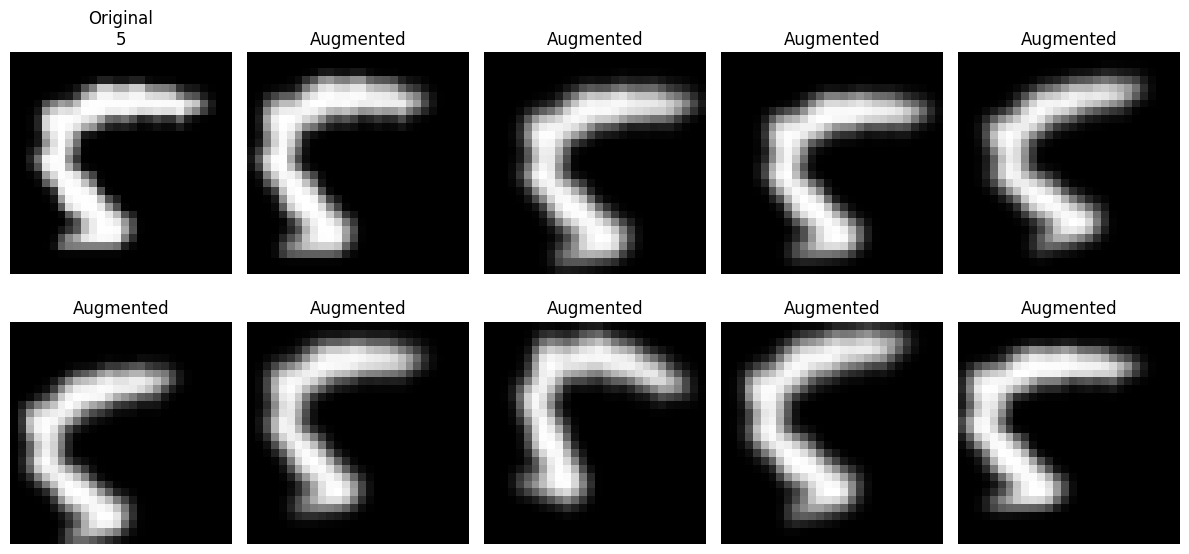

In [16]:
import matplotlib.pyplot as plt

# Select one training image
sample_image = X_train[0:1]

plt.figure(figsize=(12, 6))

# Original
plt.subplot(2, 5, 1)
plt.imshow(sample_image[0].squeeze(), cmap="gray")
plt.title(
    f"Original\n{label_mapping[int(y_train[0])]}"
)
plt.axis("off")

# Generate 9 augmented versions
for i in range(2, 11):

    augmented_image = data_augmentation(
        sample_image,
        training=True
    )

    plt.subplot(2, 5, i)
    plt.imshow(
        augmented_image[0].numpy().squeeze(),
        cmap="gray"
    )
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model_1 = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(62, activation="softmax")
])

cnn_model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,350 (1.63 MB)

 Trainable params: 428,350 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_model_1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history_cnn_1 = cnn_model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=256,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/15
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7144 - loss: 1.0064
Epoch 1: val_accuracy improved from None to 0.84797, saving model to best_cnn_model_1.keras

Epoch 1: finished saving model to best_cnn_model_1.keras
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.7873 - loss: 0.6774 - val_accuracy: 0.8480 - val_loss: 0.4300 - learning_rate: 0.0010
Epoch 2/15
2451/2454 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8355 - loss: 0.4762
Epoch 2: val_accuracy improved from 0.84797 to 0.85704, saving model to best_cnn_model_1.keras

Epoch 2: finished saving model to best_cnn_model_1.keras
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8386 - loss: 0.4655 - val_accuracy: 0.8570 - val_loss: 0.3958 - learning_rate: 0.0010
Epoch 3/15
2449/2454 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8465 - loss: 0.4357
Epoch 3: val_accuracy improved from 0.85704 to 0.86070, saving model to best_cnn_model_1.keras

Epoch 3: finished saving model to best_cnn_model_

In [20]:
test_loss_1, test_accuracy_1 = cnn_model_1.evaluate(
    X_test,
    y_test,
    batch_size=256,
    verbose=1
)

print(f"Test Loss: {test_loss_1:.4f}")
print(f"Test Accuracy: {test_accuracy_1 * 100:.2f}%")

455/455 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8704 - loss: 0.3537
Test Loss: 0.3537
Test Accuracy: 87.04%


In [21]:
best_val_accuracy_1 = max(
    history_cnn_1.history["val_accuracy"]
)

best_epoch_1 = (
    np.argmax(history_cnn_1.history["val_accuracy"]) + 1
)

print(f"Best Validation Accuracy: {best_val_accuracy_1 * 100:.2f}%")
print(f"Best Epoch: {best_epoch_1}")

Best Validation Accuracy: 87.01%
Best Epoch: 14


In [22]:
y_pred_prob_1 = cnn_model_1.predict(
    X_test,
    batch_size=256,
    verbose=1
)

y_pred_1 = np.argmax(y_pred_prob_1, axis=1)

print("Predictions generated successfully.")
print("Prediction shape:", y_pred_1.shape)

455/455 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Predictions generated successfully.
Prediction shape: (116323,)


In [23]:
from sklearn.metrics import classification_report

target_names = [
    label_mapping[i]
    for i in range(62)
]

report_1 = classification_report(
    y_test,
    y_pred_1,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report_1)

              precision    recall  f1-score   support

           0     0.6850    0.8392    0.7543      5778
           1     0.6809    0.9191    0.7823      6330
           2     0.9591    0.9782    0.9685      5869
           3     0.9920    0.9945    0.9932      5969
           4     0.9695    0.9779    0.9737      5619
           5     0.9531    0.9403    0.9467      5190
           6     0.9744    0.9818    0.9781      5705
           7     0.9872    0.9943    0.9907      6139
           8     0.9763    0.9863    0.9813      5633
           9     0.9327    0.9768    0.9542      5686
           A     0.9445    0.9774    0.9607      1062
           B     0.9353    0.9367    0.9360       648
           C     0.7785    0.9540    0.8574      1739
           D     0.8860    0.9076    0.8966       779
           E     0.9693    0.9647    0.9670       851
           F     0.7715    0.9611    0.8559      1440
           G     0.9297    0.8881    0.9085       447
           H     0.9455    

In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_2 = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Class weights calculated successfully.")

for cls in classes:
    print(
        f"{cls:2d} -> {label_mapping[int(cls)]}: "
        f"{class_weights_2[int(cls)]:.4f}"
    )

Class weights calculated successfully.
 0 -> 0: 0.3255
 1 -> 1: 0.2933
 2 -> 2: 0.3291
 3 -> 3: 0.3203
 4 -> 4: 0.3357
 5 -> 5: 0.3583
 6 -> 6: 0.3288
 7 -> 7: 0.3148
 8 -> 8: 0.3316
 9 -> 9: 0.3326
10 -> A: 1.7571
11 -> B: 2.9029
12 -> C: 1.1152
13 -> D: 2.4674
14 -> E: 2.2813
15 -> F: 1.2260
16 -> G: 4.4730
17 -> H: 3.5711
18 -> I: 0.9424
19 -> J: 2.9921
20 -> K: 4.5616
21 -> L: 2.2179
22 -> M: 1.2505
23 -> N: 1.3667
24 -> O: 0.4506
25 -> P: 1.3487
26 -> Q: 4.3204
27 -> R: 2.2188
28 -> S: 0.5421
29 -> T: 1.1463
30 -> U: 0.8933
31 -> V: 2.4278
32 -> W: 2.3979
33 -> X: 4.0623
34 -> Y: 2.3732
35 -> Z: 4.1675
36 -> a: 1.1220
37 -> b: 2.1820
38 -> c: 3.9437
39 -> d: 1.1062
40 -> e: 0.4570
41 -> f: 4.3953
42 -> g: 3.0534
43 -> h: 1.2883
44 -> i: 4.1318
45 -> j: 5.9386
46 -> k: 4.5188
47 -> l: 0.7349
48 -> m: 4.2550
49 -> n: 0.9859
50 -> o: 4.0951
51 -> p: 4.5988
52 -> q: 3.7593
53 -> r: 0.7981
54 -> s: 4.1710
55 -> t: 0.6164
56 -> u: 3.9777
57 -> v: 3.8684
58 -> w: 4.1744
59 -> x: 3.9887
6

In [26]:
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 128

AUTOTUNE = tf.data.AUTOTUNE


def prepare_efficientnet_data(image, label):
    # 28x28 -> 96x96
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Grayscale -> RGB
    image = tf.image.grayscale_to_rgb(image)

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)


train_ds = (
    train_ds
    .shuffle(10000, seed=42)
    .map(prepare_efficientnet_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(prepare_efficientnet_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(prepare_efficientnet_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("EfficientNet data pipelines created successfully.")

EfficientNet data pipelines created successfully.


In [27]:
data_augmentation_efficientnet = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(
        0.05,
        fill_mode="constant"
    ),

    tf.keras.layers.RandomTranslation(
        0.08,
        0.08,
        fill_mode="constant"
    ),

    tf.keras.layers.RandomZoom(
        0.08,
        fill_mode="constant"
    )

], name="efficientnet_augmentation")

In [29]:
IMG_SIZE = 96
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

IMG_SIZE: 96
BATCH_SIZE: 128


In [31]:
from keras import layers, Model
from keras.applications import EfficientNetB0

print("Keras EfficientNetB0 loaded successfully!")

Keras EfficientNetB0 loaded successfully!


In [33]:
from keras import layers, Model
from keras.applications import EfficientNetB0

In [34]:
from keras import layers, Model
from keras.applications import EfficientNetB0

# Input size
IMG_SIZE = 96

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
base_model.trainable = False


# Input layer
inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Data augmentation
x = data_augmentation_efficientnet(inputs)

# Pretrained EfficientNetB0
x = base_model(
    x,
    training=False
)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.40)(x)

# 62 classes
outputs = layers.Dense(
    62,
    activation="softmax"
)(x)

# Create model
efficientnet_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_EMNIST"
)

# Compile
efficientnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 model created successfully!")

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model created successfully!


Model: "EfficientNetB0_EMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_augmentation       │ (None, 96, 96, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,394,465 (16.76 MB)

 Trainable params: 344,382 (1.31 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [35]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping_en = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint_en = ModelCheckpoint(
    "best_efficientnetb0_emnist.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_en = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [37]:
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE


def prepare_efficientnet_data(image, label):
    # Resize 28x28 -> 96x96
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Grayscale -> RGB
    image = tf.image.grayscale_to_rgb(image)

    return image, label


# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_ds = (
    train_ds
    .shuffle(10000, seed=42)
    .map(
        prepare_efficientnet_data,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_ds = (
    val_ds
    .map(
        prepare_efficientnet_data,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_ds = (
    test_ds
    .map(
        prepare_efficientnet_data,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 4908
Validation batches: 546
Test batches: 909


In [38]:
for images, labels in train_ds.take(1):
    print("Batch images:", images.shape)
    print("Batch labels:", labels.shape)

Batch images: (128, 96, 96, 3)
Batch labels: (128,)


In [39]:
history_efficientnet = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights_2,
    callbacks=[
        early_stopping_en,
        checkpoint_en,
        reduce_lr_en
    ],
    verbose=1
)

Epoch 1/8
4907/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0559 - loss: 3.9087
Epoch 1: val_accuracy improved from None to 0.06919, saving model to best_efficientnetb0_emnist.keras

Epoch 1: finished saving model to best_efficientnetb0_emnist.keras
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 376s 74ms/step - accuracy: 0.1040 - loss: 3.5284 - val_accuracy: 0.0692 - val_loss: 7.1947 - learning_rate: 0.0010
Epoch 2/8
4907/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1890 - loss: 2.9694
Epoch 2: val_accuracy did not improve from 0.06919
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 364s 74ms/step - accuracy: 0.2033 - loss: 2.8977 - val_accuracy: 0.0371 - val_loss: 6.0343 - learning_rate: 0.0010
Epoch 3/8
4907/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2362 - loss: 2.7383
Epoch 3: val_accuracy did not improve from 0.06919

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 374s 73ms/step - accuracy: 0.2440 - loss: 2.7059 - val_accuracy:

In [40]:
# Save final CNN model
FINAL_MODEL_PATH = "/content/final_emnist_cnn.keras"

cnn_model_1.save(FINAL_MODEL_PATH)

print("Final CNN model saved successfully!")
print("Path:", FINAL_MODEL_PATH)

Final CNN model saved successfully!
Path: /content/final_emnist_cnn.keras


In [41]:
import json

LABEL_MAPPING_PATH = "/content/emnist_label_mapping.json"

with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(
        {str(k): v for k, v in label_mapping.items()},
        f,
        indent=4
    )

print("Label mapping saved successfully!")

Label mapping saved successfully!


In [42]:
!pip install -q gradio

In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

final_cnn_model = tf.keras.models.load_model(
    "/content/final_emnist_cnn.keras"
)

print("Final CNN loaded successfully!")

Final CNN loaded successfully!


In [44]:
def preprocess_uploaded_image(image):
    """
    Convert uploaded handwritten character into
    EMNIST-style 28x28 grayscale input.
    """

    if image is None:
        return None

    # Convert to grayscale
    image = Image.fromarray(image).convert("L")

    # Convert to numpy
    img = np.array(image)

    # Automatically determine whether background is dark or light
    if np.mean(img) > 127:
        img = 255 - img

    # Threshold to find character
    threshold = 30
    mask = img > threshold

    # If no character detected
    if not np.any(mask):
        return None

    # Find bounding box
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]

    # Crop
    cropped = img[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    # Make square canvas
    h, w = cropped.shape
    size = max(h, w)

    canvas = np.zeros(
        (size, size),
        dtype=np.uint8
    )

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    canvas[
        y_offset:y_offset + h,
        x_offset:x_offset + w
    ] = cropped

    # Resize to 24x24
    character = Image.fromarray(canvas).resize(
        (24, 24),
        Image.Resampling.LANCZOS
    )

    # Put inside 28x28 canvas
    final_img = Image.new(
        "L",
        (28, 28),
        0
    )

    final_img.paste(
        character,
        (2, 2)
    )

    return np.array(final_img)

In [45]:
emotion_labels = [
    label_mapping[i]
    for i in range(62)
]


def predict_character(image):

    if image is None:
        return (
            "No Image",
            "Please upload a handwritten character.",
            None
        )

    processed = preprocess_uploaded_image(image)

    if processed is None:
        return (
            "Not Detected",
            "No handwritten character was detected.",
            None
        )

    # Normalize
    input_image = processed.astype("float32") / 255.0

    # Add channel dimension
    input_image = input_image[..., np.newaxis]

    # Add batch dimension
    input_image = np.expand_dims(
        input_image,
        axis=0
    )

    # Prediction
    probabilities = final_cnn_model.predict(
        input_image,
        verbose=0
    )[0]

    # Best prediction
    predicted_index = np.argmax(probabilities)

    predicted_character = emotion_labels[predicted_index]

    confidence = probabilities[predicted_index] * 100

    # Top 5 predictions
    top_indices = np.argsort(
        probabilities
    )[::-1][:5]

    top_predictions = []

    for idx in top_indices:
        top_predictions.append(
            f"{emotion_labels[idx]}: "
            f"{probabilities[idx] * 100:.2f}%"
        )

    top_text = "\n".join(top_predictions)

    return (
        predicted_character,
        f"{confidence:.2f}%",
        top_text
    )

In [46]:
import gradio as gr

css = """
/* Main background */
body {
    background: #050816 !important;
}

.gradio-container {
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(99, 102, 241, 0.18),
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 20%,
            rgba(34, 211, 238, 0.12),
            transparent 28%
        ),
        #050816 !important;

    color: #f8fafc !important;
    max-width: 1250px !important;
}

/* Hero */
.hero {
    text-align: center;
    padding: 35px 20px 25px;
}

.hero h1 {
    font-size: 46px;
    font-weight: 800;
    margin-bottom: 10px;

    background: linear-gradient(
        90deg,
        #818cf8,
        #c084fc,
        #22d3ee
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero p {
    color: #94a3b8;
    font-size: 17px;
}

/* Cards */
.glass-card {
    background: rgba(15, 23, 42, 0.75);
    border: 1px solid rgba(148, 163, 184, 0.16);
    border-radius: 22px;
    padding: 22px;
    box-shadow: 0 20px 60px rgba(0,0,0,0.30);
}

/* Result */
.result-card {
    background: linear-gradient(
        135deg,
        rgba(79,70,229,0.22),
        rgba(14,165,233,0.12)
    );

    border: 1px solid rgba(129,140,248,0.30);
    border-radius: 22px;
    padding: 28px;
    text-align: center;
}

.result-character {
    font-size: 90px;
    font-weight: 900;

    background: linear-gradient(
        135deg,
        #818cf8,
        #22d3ee
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

/* Buttons */
button {
    border-radius: 14px !important;
}

/* Upload */
.upload-area {
    border-radius: 18px !important;
}

/* Stats */
.stat {
    text-align: center;
    padding: 18px;
    border-radius: 18px;
    background: rgba(30,41,59,0.55);
    border: 1px solid rgba(148,163,184,0.12);
}

.stat-number {
    font-size: 28px;
    font-weight: 800;
    color: #a5b4fc;
}

.stat-label {
    color: #94a3b8;
    font-size: 13px;
}
"""

In [ ]:
with gr.Blocks(
    css=css,
    theme=gr.themes.Base()
) as demo:

    # HERO
    gr.HTML("""
    <div class="hero">
        <h1>Handwritten Character Recognition</h1>
        <p>
            AI-powered recognition of handwritten digits,
            uppercase and lowercase characters
        </p>
    </div>
    """)

    # MODEL STATS
    gr.HTML("""
    <div style="
        display:grid;
        grid-template-columns:
        repeat(4, 1fr);
        gap:15px;
        margin-bottom:25px;
    ">

        <div class="stat">
            <div class="stat-number">87.04%</div>
            <div class="stat-label">Test Accuracy</div>
        </div>

        <div class="stat">
            <div class="stat-number">74.18%</div>
            <div class="stat-label">Macro F1</div>
        </div>

        <div class="stat">
            <div class="stat-number">62</div>
            <div class="stat-label">Character Classes</div>
        </div>

        <div class="stat">
            <div class="stat-number">CNN</div>
            <div class="stat-label">Final Model</div>
        </div>

    </div>
    """)

    with gr.Row():

        # LEFT
        with gr.Column(
            scale=1,
            elem_classes="glass-card"
        ):

            gr.Markdown(
                "### Upload Handwritten Character"
            )

            input_image = gr.Image(
                type="numpy",
                image_mode="RGB",
                label="Upload Image",
                height=330
            )

            predict_btn = gr.Button(
                "Recognize Character",
                variant="primary",
                size="lg"
            )

            clear_btn = gr.ClearButton(
                components=[input_image],
                value="Clear"
            )


        # RIGHT
        with gr.Column(
            scale=1,
            elem_classes="glass-card"
        ):

            gr.Markdown(
                "### Recognition Result"
            )

            result_character = gr.Textbox(
                label="Predicted Character",
                interactive=False,
                text_align="center"
            )

            confidence = gr.Textbox(
                label="Confidence",
                interactive=False,
                text_align="center"
            )

            top_predictions = gr.Textbox(
                label="Top 5 Predictions",
                lines=6,
                interactive=False
            )

            gr.Markdown("""
            **Model:** Custom Convolutional Neural Network
            **Dataset:** EMNIST ByClass
            **Classes:** 62
            **Test Accuracy:** 87.04%
            """)


    # HOW IT WORKS
    gr.HTML("""
    <div style="
        margin-top:25px;
        padding:25px;
        border-radius:22px;
        background:rgba(15,23,42,0.65);
        border:1px solid rgba(148,163,184,0.12);
    ">

        <h2 style="text-align:center;">
            How It Works
        </h2>

        <div style="
            display:grid;
            grid-template-columns:
            repeat(4, 1fr);
            gap:15px;
            text-align:center;
            margin-top:20px;
        ">

            <div>
                <h3>01</h3>
                <p>Upload Image</p>
            </div>

            <div>
                <h3>02</h3>
                <p>Preprocess</p>
            </div>

            <div>
                <h3>03</h3>
                <p>CNN Prediction</p>
            </div>

            <div>
                <h3>04</h3>
                <p>Character Result</p>
            </div>

        </div>
    </div>
    """)


    # EVENTS
    predict_btn.click(
        fn=predict_character,
        inputs=input_image,
        outputs=[
            result_character,
            confidence,
            top_predictions
        ]
    )


demo.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_5409/2456163386.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a52048df8d6bb58828.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
